In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import st_clustering as stc
import seaborn as sns
import os

In [3]:
np.random.seed(0)

In [4]:
df = pd.read_csv('z_matrix_after_ipca.csv')
df_with_time = df
df_without_time = df.iloc[:, 2:]

In [5]:
# normalize the data 
df['ipca1'] = (df['ipca1'] - df['ipca1'].min()) / (df['ipca1'].max() - df['ipca1'].min())
df['ipca2'] = (df['ipca2'] - df['ipca2'].min()) / (df['ipca2'].max() - df['ipca2'].min())
# transform to numpy array
data = df.loc[:, ['time','ipca1', 'ipca2']].values

In [6]:
st_spectral = stc.ST_SpectralClustering(
    eps1=0.1,
    eps2=20,
    n_clusters=3
)
st_spectral.st_fit(data)   # NOT frame split

D:\Conda\envs\stcluster\lib\site-packages\st_clustering\st_clustering.py:31: UserWarning: As input data is very large, clustering probably will take some time. Thus, if clustering takes too long, it might make sense to use st_fit_frame_split method.
  warnings.warn('As input data is very large, clustering probably will take some time. Thus, if clustering takes too long, it might make sense to use st_fit_frame_split method.')
D:\Conda\envs\stcluster\lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Conda\envs\stcluster\lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
  File "D:\Conda\envs\stcluster\lib\subprocess.py", l

ST_SpectralClustering(eps1=0.1, eps2=20, n_clusters=3)

In [7]:
df['st_labels'] = st_spectral.labels

In [8]:
df_hops = pd.read_csv("Hopping_Information.csv")

# apply time cutoff
df_hops = df_hops[df_hops["time"] <= 57.8].reset_index(drop=True)

In [9]:
df_plot = df[df["time"] <= 57.8].reset_index(drop=True) ## on the ipca/rearranged csv

data_plot = df_plot.loc[:, ["ipca1", "ipca2"]].values
## : selects all rows. ["ipca1", "ipca2"] selects only the two columns
labels_st = df_plot["st_labels"].values

In [10]:
hop_mask = (df_hops["Hops2.1"] == 1) | (df_hops["Hops1.2"] == 1)
df_plot["is_hop"] = hop_mask.values # this creates a new column in ipca/rearranged csv after >57.8 rows removed

In [11]:
df_zmt = pd.read_csv("Z_Matrix (raw).csv")
df_zmt = df_zmt.sort_values(["time", "traj"]).reset_index(drop=True)
df_zmt = df_zmt[["time", "traj"] + [c for c in df_zmt.columns if c not in ["time", "traj"]]]
df_zmt = df_zmt[df_zmt["time"] <= 57.8].reset_index(drop=True)

df_zmt_st = df_zmt.copy()
df_zmt_st["st_labels"] = df["st_labels"].values
df_zmt_st.head()

,time,traj,r21,r32,r43,r54,r65,r71,r82,r9.3,...,d4.3.2.1,d5.4.3.2,d6.5.4.3,d7.1.2.3,d8.2.1.3,d9.3.2.1,d10.4.3.2,d11.6.5.4,d12654,st_labels
0,0.0,1,1.447360,1.529240,1.365330,1.524298,1.338307,0.995543,1.019582,1.051487,...,-3.223870,9.300478,172.316382,171.230514,-173.922934,-159.814224,161.757855,-173.820349,-9.632035,0
1,0.0,2,1.372375,1.467465,1.390720,1.469328,1.322474,1.239468,1.042864,1.132168,...,6.744138,-9.548229,176.683922,-156.512496,177.028713,162.933871,-177.581177,166.347020,12.110549,0
2,0.0,3,1.337090,1.479671,1.302191,1.459196,1.366717,0.943013,1.097645,1.052629,...,-5.686923,6.706174,176.535649,-172.735375,175.121607,-175.045324,172.995026,177.234384,-8.085807,0
3,0.0,4,1.344334,1.593410,1.401025,1.475301,1.387491,0.972401,0.991424,1.101421,...,-5.385660,9.074238,-177.874183,176.803384,-167.561997,165.671081,172.393407,164.083305,-9.656004,0
4,0.0,5,1.300993,1.475554,1.400136,1.524640,1.316638,1.160136,0.990294,1.006074,...,4.891420,-4.337337,-175.155219,163.607619,172.863660,155.685091,175.630540,-163.273545,-4.116360,0


In [12]:
# normalize the data 
df_without_time['ipca1'] = (df_without_time['ipca1'] - df_without_time['ipca1'].min()) / (df_without_time['ipca1'].max() - df_without_time['ipca1'].min())
df_without_time['ipca2'] = (df_without_time['ipca2'] - df_without_time['ipca2'].min()) / (df_without_time['ipca2'].max() - df_without_time['ipca2'].min())
# transform to numpy array
data = df_without_time[['ipca1', 'ipca2']].values

In [13]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=3,
    assign_labels="discretize",
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=0
)

labels = spectral.fit_predict(data)
df["nonst_labels"] = labels

In [14]:
# read ULaMDyn properties / hops CSV
df_hops = pd.read_csv("Hopping_Information.csv")

# apply time cutoff
df_hops = df_hops[df_hops["time"] <= 57.8].reset_index(drop=True)

In [15]:
df_plot = df[df["time"] <= 57.8].reset_index(drop=True)

data_plot = df_plot.loc[:, ["ipca1", "ipca2"]].values
labels_nonst = df_plot["nonst_labels"].values

In [16]:
hop_mask = (df_hops["Hops2.1"] == 1) | (df_hops["Hops1.2"] == 1)
df_plot["is_hop"] = hop_mask.values

df_zmt_nonst = df_zmt.copy()
df_zmt_nonst['nonst_labels'] = df['nonst_labels'].values
df_zmt_nonst.head()

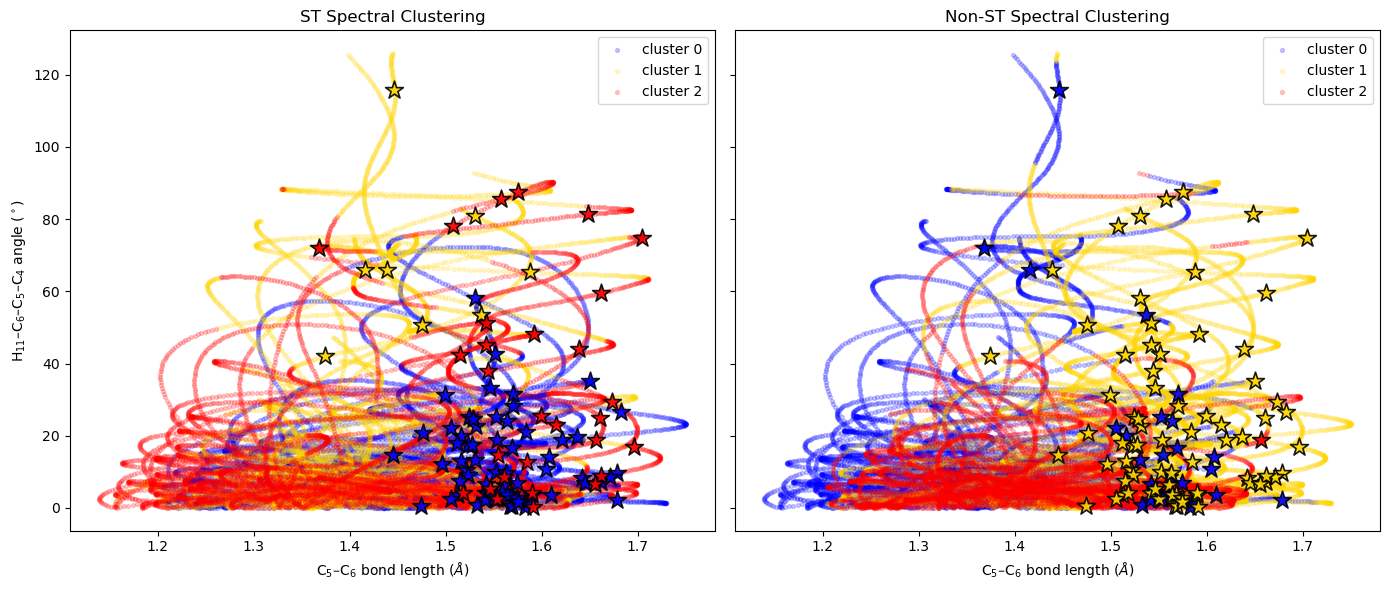

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# =========================
# Plot 1: ST
# =========================
ax = axes[0]

cluster_labels = sorted(df_zmt_st['st_labels'].unique())
colors = ['blue', 'gold', 'red']

idx_hops = df_hops[
    (df_hops['Hops2.1'] == 1) | (df_hops['Hops1.2'] == 1)
].index.tolist()

for l, c in zip(cluster_labels, colors):
    zmt = df_zmt_st[df_zmt_st['st_labels'] == l].abs()
    ax.scatter(
        zmt['r65'], zmt['d12654'],
        s=8, c=c, alpha=0.2,
        label=f'cluster {l}'
    )

    df_zmt_hops = df_zmt_st.loc[idx_hops]
    zmt = df_zmt_hops[df_zmt_hops['st_labels'] == l].abs()
    if not zmt.empty:
        ax.scatter(
            zmt['r65'], zmt['d12654'],
            s=180, marker='*',
            c=c, edgecolors='black',
            linewidths=1.2,
            alpha=0.9,
            zorder=5
        )

ax.set_title('ST Spectral Clustering')
ax.set_xlabel('C$_5$–C$_6$ bond length ($\AA$)')
ax.set_ylabel('H$_{11}$–C$_6$–C$_5$–C$_4$ angle ($^\circ$)')
ax.legend()


# =========================
# Plot 2: Non-ST
# =========================
ax = axes[1]

cluster_labels = sorted(df_zmt_nonst['nonst_labels'].unique())

for l, c in zip(cluster_labels, colors):
    zmt = df_zmt_nonst[df_zmt_nonst['nonst_labels'] == l].abs()
    ax.scatter(
        zmt['r65'], zmt['d12654'],
        s=8, c=c, alpha=0.2,
        label=f'cluster {l}'
    )

    df_zmt_hops = df_zmt_nonst.loc[idx_hops]
    zmt = df_zmt_hops[df_zmt_hops['nonst_labels'] == l].abs()
    if not zmt.empty:
        ax.scatter(
            zmt['r65'], zmt['d12654'],
            s=180, marker='*',
            c=c, edgecolors='black',
            linewidths=1.2,
            alpha=0.9,
            zorder=5
        )

ax.set_title('Non-ST Spectral Clustering')
ax.set_xlabel('C$_5$–C$_6$ bond length ($\AA$)')
ax.legend()

plt.tight_layout()
plt.show()

In [42]:
df_zmatrix_ipca_st = pd.read_csv("z_matrix_after_ipca.csv")
df_zmatrix_ipca_st["st_labels"] = df["st_labels"].values

In [46]:
df_zmatrix_ipca_nonst = pd.read_csv("z_matrix_after_ipca.csv")
df_zmatrix_ipca_nonst["nonst_labels"] = df["nonst_labels"].values

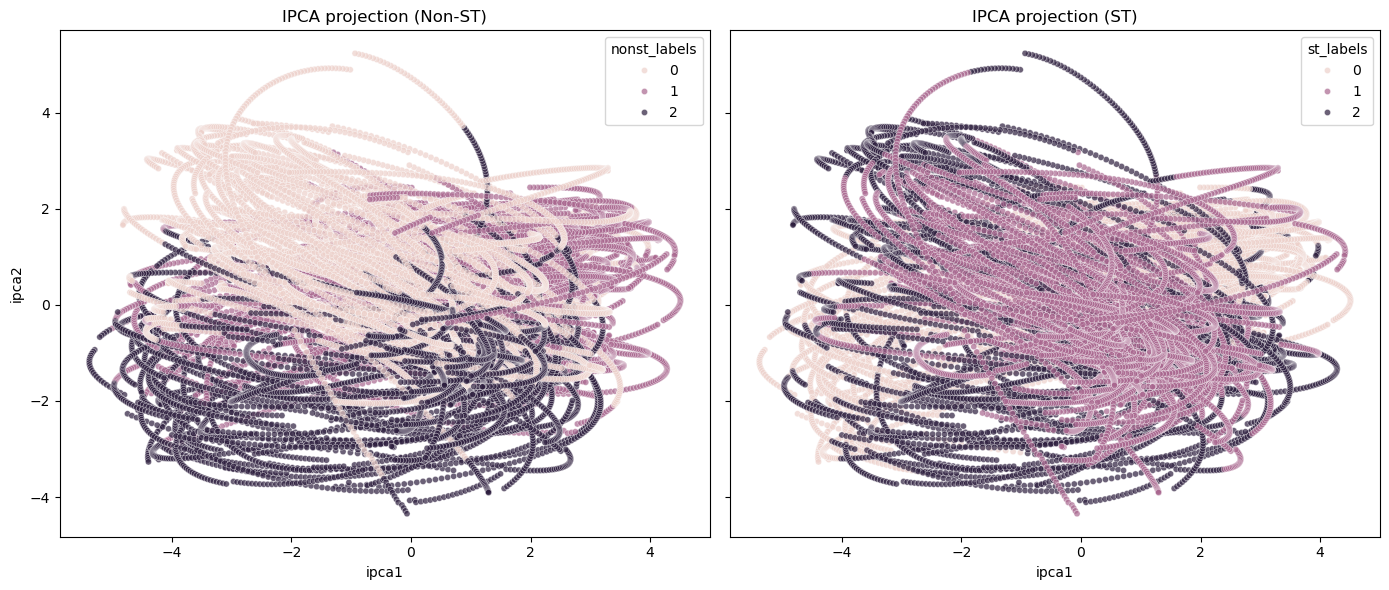

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ---------- Non-ST ----------
sns.scatterplot(
    data=df_zmatrix_ipca_nonst,
    x="ipca1",
    y="ipca2",
    hue="nonst_labels",
    alpha=0.7,
    s=20,
    ax=axes[0]
)
axes[0].set_title("IPCA projection (Non-ST)")
axes[0].set_xlabel("ipca1")
axes[0].set_ylabel("ipca2")
axes[0].legend(title="nonst_labels")

# ---------- ST ----------
sns.scatterplot(
    data=df_zmatrix_ipca_st,
    x="ipca1",
    y="ipca2",
    hue="st_labels",
    alpha=0.7,
    s=20,
    ax=axes[1]
)
axes[1].set_title("IPCA projection (ST)")
axes[1].set_xlabel("ipca1")
axes[1].set_ylabel("ipca2")
axes[1].legend(title="st_labels")

plt.tight_layout()
plt.show()

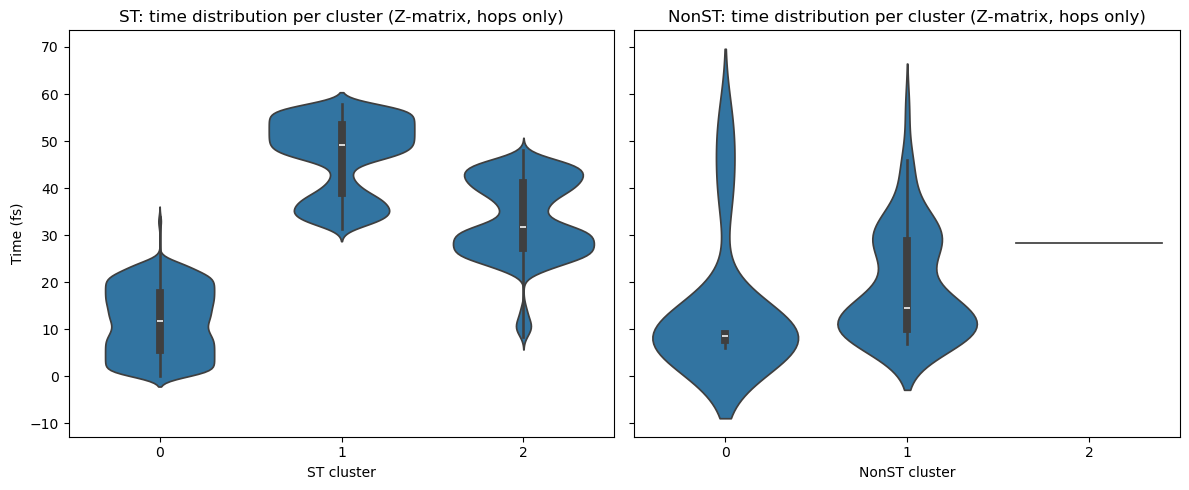

In [50]:
df_zmatrix_ipca_st_hops = df_zmatrix_ipca_st.loc[hop_mask].reset_index(drop=True)
df_zmatrix_ipca_nonst_hops = df_zmatrix_ipca_nonst.loc[hop_mask].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ===== ST =====
sns.violinplot(
    x="st_labels",
    y="time",
    data=df_zmatrix_ipca_st,
    inner="box",
    ax=axes[0]
)
axes[0].set_title("ST: time distribution per cluster (Z-matrix, hops only)")
axes[0].set_xlabel("ST cluster")
axes[0].set_ylabel("Time (fs)")

# ===== Non-ST =====
sns.violinplot(
    x="nonst_labels",
    y="time",
    data=df_zmatrix_ipca_nonst_hops,
    inner="box",
    ax=axes[1]
)
axes[1].set_title("NonST: time distribution per cluster (Z-matrix, hops only)")
axes[1].set_xlabel("NonST cluster")

plt.tight_layout()
plt.show()
